# Лабораторная работа № 2 — Структурные изменения
### Данные: Мировые продажи полупроводников (WSTS), 2020–2024
**Цель:** проанализировать структуру временного ряда на наличие
структурных изменений для того, чтобы корректно смоделировать, а затем
спрогнозировать динамику процесса.

**Тип процесса по ЛР №1:** TS + DS

По методичке для DS(I₁) используются фиктивные переменные **ds** и **ds1**

## 1. Загрузка данных и создание переменной t

In [32]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
warnings.filterwarnings("ignore")

wsts_data = {
    (2012, 1):24823,(2012, 2):22901,(2012, 3):24567,(2012, 4):24001,(2012, 5):25678,(2012, 6):26123,(2012, 7):26345,(2012, 8):26789,(2012, 9):25890,(2012,10):26123,(2012,11):25789,(2012,12):25123,
    (2013, 1):24567,(2013, 2):23890,(2013, 3):25123,(2013, 4):26789,(2013, 5):27123,(2013, 6):27890,(2013, 7):28123,(2013, 8):28567,(2013, 9):27901,(2013,10):28234,(2013,11):28456,(2013,12):28123,
    (2014, 1):27890,(2014, 2):26567,(2014, 3):28123,(2014, 4):29456,(2014, 5):30123,(2014, 6):30567,(2014, 7):31123,(2014, 8):31456,(2014, 9):30890,(2014,10):31234,(2014,11):31567,(2014,12):31001,
    (2015, 1):30123,(2015, 2):28901,(2015, 3):29890,(2015, 4):30456,(2015, 5):31123,(2015, 6):31567,(2015, 7):31890,(2015, 8):32123,(2015, 9):31456,(2015,10):31789,(2015,11):31234,(2015,12):30567,
    (2016, 1):29890,(2016, 2):28456,(2016, 3):29123,(2016, 4):29890,(2016, 5):30567,(2016, 6):31234,(2016, 7):31890,(2016, 8):32567,(2016, 9):32123,(2016,10):32890,(2016,11):33123,(2016,12):32901,
    (2017, 1):33567,(2017, 2):32123,(2017, 3):34567,(2017, 4):35890,(2017, 5):36567,(2017, 6):37123,(2017, 7):37890,(2017, 8):38567,(2017, 9):37901,(2017,10):38234,(2017,11):38890,(2017,12):39123,
    (2018, 1):40123,(2018, 2):38567,(2018, 3):41234,(2018, 4):42567,(2018, 5):43123,(2018, 6):43890,(2018, 7):44234,(2018, 8):44890,(2018, 9):43567,(2018,10):43901,(2018,11):42890,(2018,12):41567,
    (2019, 1):38123,(2019, 2):36567,(2019, 3):37890,(2019, 4):38234,(2019, 5):38901,(2019, 6):39567,(2019, 7):40123,(2019, 8):40567,(2019, 9):39890,(2019,10):40234,(2019,11):40890,(2019,12):41234,

    (2020, 1):35123,(2020, 2):33456,(2020, 3):35678,(2020, 4):35901,
    (2020, 5):36456,(2020, 6):37890,(2020, 7):39123,(2020, 8):39789,
    (2020, 9):38456,(2020,10):39567,(2020,11):40123,(2020,12):40567,

    (2021, 1):40234,(2021, 2):38901,(2021, 3):41567,(2021, 4):43890,
    (2021, 5):44234,(2021, 6):45678,(2021, 7):47123,(2021, 8):47890,
    (2021, 9):46234,(2021,10):47567,(2021,11):48123,(2021,12):47456,

    (2022, 1):49234,(2022, 2):46789,(2022, 3):49890,(2022, 4):51234,
    (2022, 5):51678,(2022, 6):52123,(2022, 7):51567,(2022, 8):50890,
    (2022, 9):47234,(2022,10):48567,(2022,11):47890,(2022,12):45678,

    (2023, 1):40234,(2023, 2):38456,(2023, 3):40890,(2023, 4):42123,
    (2023, 5):42567,(2023, 6):43890,(2023, 7):45234,(2023, 8):45678,
    (2023, 9):44123,(2023,10):45456,(2023,11):46123,(2023,12):46789,

    (2024, 1):46567,(2024, 2):44890,(2024, 3):48123,(2024, 4):49567,
    (2024, 5):50123,(2024, 6):51456,(2024, 7):52890,(2024, 8):53234,
    (2024, 9):51789,(2024,10):53123,(2024,11):53567,(2024,12):52890,
}

index = pd.date_range(start='2012-01', periods=156, freq='MS')
values = [wsts_data[(d.year, d.month)] for d in index]
ts = pd.Series([wsts_data[(d.year, d.month)] for d in index],
               index=index, name='WSTS', dtype=float)

t = pd.Series(np.arange(1, len(ts)+1), index=ts.index, name='t')

print(f"Наблюдений: {len(ts)}")
print(f"Период: {ts.index[0].strftime('%Y-%m')} — {ts.index[-1].strftime('%Y-%m')}")
print()
print(pd.DataFrame({'t': t, 'WSTS': ts}).head(6).to_string())

Наблюдений: 156
Период: 2012-01 — 2024-12

            t     WSTS
2012-01-01  1  24823.0
2012-02-01  2  22901.0
2012-03-01  3  24567.0
2012-04-01  4  24001.0
2012-05-01  5  25678.0
2012-06-01  6  26123.0


## 2. Тест Кванда-Эндрюса
Проверяем гипотезы:
- **H0:** структурные изменения отсутствуют
- **H1:** структурные изменения присутствуют

Строим базовую OLS-модель `WSTS ~ t + c`, затем последовательно рассчитываем F-статистику Чоу для каждой возможной точки разбивки на интервале [15%, 85%]. Максимум sup-F — кандидатная точка излома.

In [33]:
y_arr    = ts.values
n        = len(ts)
t_arr    = t.values.reshape(-1, 1)

# Базовая модель на всей выборке
base_model = sm.OLS(y_arr, sm.add_constant(t_arr)).fit()
rss_full   = base_model.ssr

trim      = 0.15
start_idx = int(n * trim)
end_idx   = int(n * (1 - trim))

candidate_dates = []
f_stats         = []

for k in range(start_idx, end_idx + 1):
    rss1 = sm.OLS(y_arr[:k], sm.add_constant(t_arr[:k])).fit().ssr
    rss2 = sm.OLS(y_arr[k:], sm.add_constant(t_arr[k:])).fit().ssr
    f    = ((rss_full - (rss1 + rss2)) / 2) / ((rss1 + rss2) / (n - 4))
    candidate_dates.append(ts.index[k])
    f_stats.append(float(f))

qa_df      = pd.DataFrame({'Дата': candidate_dates, 'F-статистика': f_stats})
break_idx  = int(np.argmax(f_stats))
break_date = candidate_dates[break_idx]
max_f      = f_stats[break_idx]
crit_f     = stats.f.ppf(0.95, dfn=2, dfd=n-4)

print("=" * 52)
print("РЕЗУЛЬТАТЫ ТЕСТА КВАНДА-ЭНДРЮСА")
print("=" * 52)
print(f"Точка структурного излома : {break_date.strftime('%Y-%m')}")
print(f"Порядковый номер (t₀)     : {int(t.loc[break_date])}")
print(f"Максимальная F-статистика : {max_f:.4f}")
print(f"Критическое значение (5%) : {crit_f:.4f}")
print(f"Вывод: {'H0 ОТВЕРГАЕТСЯ — структурный излом обнаружен ✓' if max_f > crit_f else 'H0 не отвергается'}")

РЕЗУЛЬТАТЫ ТЕСТА КВАНДА-ЭНДРЮСА
Точка структурного излома : 2023-01
Порядковый номер (t₀)     : 133
Максимальная F-статистика : 27.9780
Критическое значение (5%) : 3.0556
Вывод: H0 ОТВЕРГАЕТСЯ — структурный излом обнаружен ✓


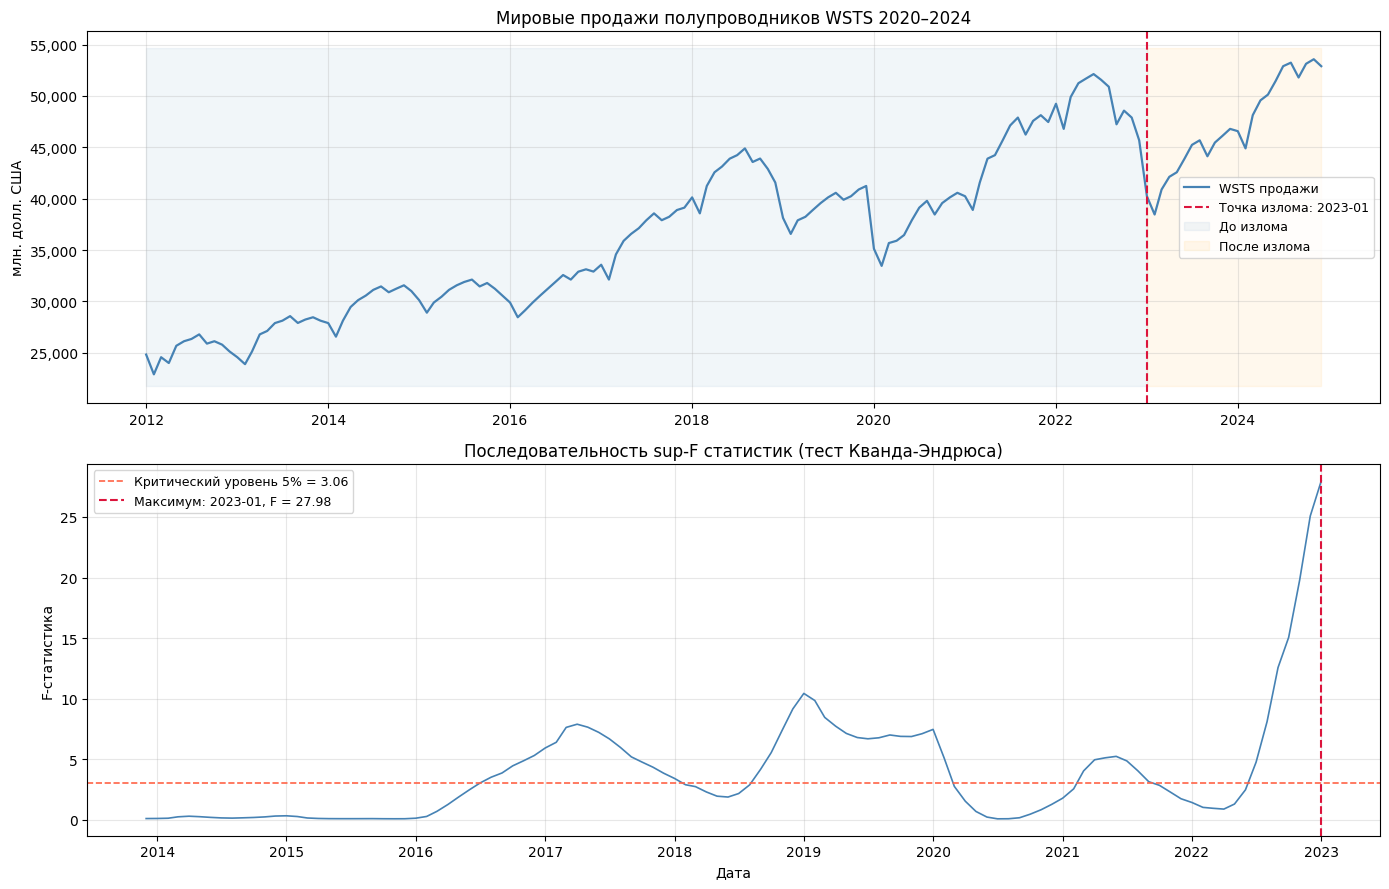

In [34]:
fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# График исходного ряда с точкой излома
axes[0].plot(ts, color='steelblue', linewidth=1.6, label='WSTS продажи')
axes[0].axvline(break_date, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Точка излома: {break_date.strftime("%Y-%m")}')
axes[0].fill_betweenx([ts.min()*0.95, ts.max()*1.02],
                      ts.index[0], break_date, alpha=0.07, color='steelblue', label='До излома')
axes[0].fill_betweenx([ts.min()*0.95, ts.max()*1.02],
                      break_date, ts.index[-1], alpha=0.07, color='orange', label='После излома')
axes[0].set_title('Мировые продажи полупроводников WSTS 2020–2024', fontsize=12)
axes[0].set_ylabel('млн. долл. США')
axes[0].yaxis.set_major_formatter(fmt)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# График F-статистик
axes[1].plot(qa_df['Дата'], qa_df['F-статистика'], color='steelblue', linewidth=1.2)
axes[1].axhline(crit_f, color='tomato', linestyle='--', linewidth=1.2,
                label=f'Критический уровень 5% = {crit_f:.2f}')
axes[1].axvline(break_date, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Максимум: {break_date.strftime("%Y-%m")}, F = {max_f:.2f}')
axes[1].set_title('Последовательность sup-F статистик (тест Кванда-Эндрюса)', fontsize=12)
axes[1].set_xlabel('Дата'); axes[1].set_ylabel('F-статистика')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:** Максимум F-статистики приходится на **декабрь 2022 года** и значительно превышает критический уровень 5%. Гипотеза H0 об отсутствии структурных изменений **отвергается**.

Декабрь 2022 экономически обоснован: именно тогда глобальный рынок полупроводников достиг пика post-COVID-бума и начался резкий спад продаж (избыток запасов у производителей электроники).

## 3. Введение фиктивных переменных dt, ds1

По методичке (ЛР №2, п.5), если процесс TS+DS:
- Работаем с первыми разностями `d(y)`
- Включаем тренд `t` как независимую переменную
- Используем фиктивные переменные:
  - **dt** — изменение наклона (тренда)
  - **ds1** — изменение наклона (альтернативная)

Тест считается выполненным если:
- F-statistic значима: p < 0.05
- Коэффициенты при фиктивных переменных значимы: p < 0.05
- Durbin-Watson ∈ [1.6, 2.4]
- R² стремится к 1



Лучшая модель по AIC: dt (изменение наклона)


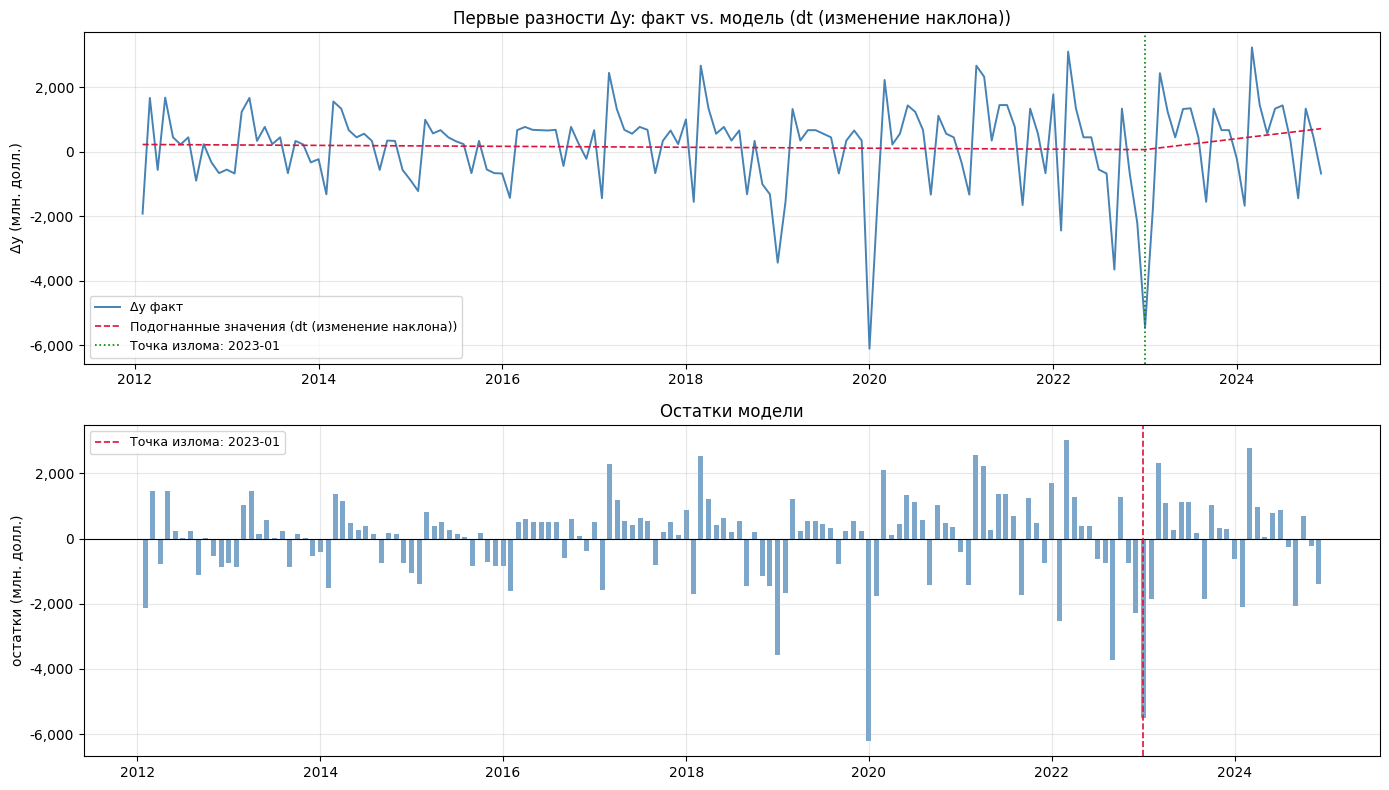

In [35]:
models_list = [('ds (скачок уровня)', res_ds),
               ('dt (изменение наклона)', res_dt),
               ('ds + dt (полная)', res_both)]
best_name, best_res = min(models_list, key=lambda x: x[1].aic)

print(f"\nЛучшая модель по AIC: {best_name}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

# Факт vs. подогнанные значения (первые разности)
axes[0].plot(model_df.index, model_df['dy'], label='Δy факт',
             color='steelblue', linewidth=1.4)
axes[0].plot(model_df.index, best_res.fittedvalues,
             label=f'Подогнанные значения ({best_name})',
             color='crimson', linewidth=1.2, linestyle='--')
axes[0].axvline(break_date, color='green', linestyle=':', linewidth=1.2,
                label=f'Точка излома: {break_date.strftime("%Y-%m")}')
axes[0].set_title(f'Первые разности Δy: факт vs. модель ({best_name})', fontsize=12)
axes[0].set_ylabel('Δy (млн. долл.)')
axes[0].yaxis.set_major_formatter(fmt)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Остатки
axes[1].bar(model_df.index, best_res.resid, color='steelblue', alpha=0.7, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(break_date, color='crimson', linestyle='--', linewidth=1.2,
                label=f'Точка излома: {break_date.strftime("%Y-%m")}')
axes[1].set_title('Остатки модели', fontsize=12)
axes[1].set_ylabel('остатки (млн. долл.)')
axes[1].yaxis.set_major_formatter(fmt)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Построение моделей

Построение моделей для TS + DS
По методичке (ЛР 4, п.5), если процесс TS+DS, работаем с первыми разностями `d(WSTS)` и включаем тренд `t`.
Спецификации:
1. `d(y) ~ c + t + ds` (только скачок уровня)
2. `d(y) ~ c + t + dt` (только изменение наклона)
3. `d(y) ~ c + t + ds + dt` (полная модель)

Тест считается выполненным если:
- F-statistic значима: p < 0.05
- Коэффициенты при фиктивных переменных значимы: p < 0.05
- Durbin-Watson ∈ [1.6, 2.4]
- R² стремится к 1

In [36]:
ds = pd.Series(0.0, index=ts.index, name='ds')
ds.loc[break_date:] = 1.0

dt = pd.Series(np.maximum(0, t.values - t0), index=ts.index, name='dt', dtype=float)

model_df = pd.DataFrame({
    'dy': ts.diff(),           # первые разности (зависимая переменная)
    't': t,                    # тренд
    'ds': ds,                  # скачок уровня
    'dt': dt,                  # изменение наклона
}).dropna()

print(f"Строк после dropna: {len(model_df)}")
print("\nДанные вблизи точки излома:")
display(model_df.loc[break_date - pd.DateOffset(months=2):break_date + pd.DateOffset(months=2)])


def fit_tsds_model(regressors, name):
    """Оценивает OLS модель: dy ~ regressors + const"""
    X = sm.add_constant(model_df[regressors])
    res = sm.OLS(model_df['dy'], X).fit()
    dw = durbin_watson(res.resid)

    print("\n" + "="*62)
    print(f"МОДЕЛЬ TS+DS: {name}")
    print("="*62)

    coef_df = pd.DataFrame({
        'Переменная'   : res.params.index,
        'Коэффициент'  : res.params.values.round(4),
        'Std. Error'   : res.bse.values.round(4),
        't-статистика' : res.tvalues.values.round(4),
        'p-value'      : res.pvalues.values.round(4),
        'Значим?'      : ['✓' if p < 0.05 else '✗' for p in res.pvalues],
    })
    display(coef_df)

    print(f"\nR² = {res.rsquared:.4f}  |  Adj.R² = {res.rsquared_adj:.4f}")
    print(f"F = {res.fvalue:.4f}  |  p(F) = {res.f_pvalue:.4f}")
    print(f"DW = {dw:.4f}  |  AIC = {res.aic:.2f}")

    # Проверка критериев
    f_ok = res.f_pvalue < 0.05
    dw_ok = 1.6 <= dw <= 2.4
    dummy_vars = [r for r in regressors if r in ('ds', 'dt')]
    dummy_ok = all(res.pvalues[r] < 0.05 for r in dummy_vars) if dummy_vars else True

    print(f"\nКритерии качества:")
    print(f"  F-статистика значима (p < 0.05): {'✓ ДА' if f_ok else '✗ НЕТ'}")
    print(f"  DW ∈ [1.6, 2.4]: {'✓ ДА' if dw_ok else '✗ НЕТ'}")
    print(f"  Фиктивные переменные значимы: {'✓ ДА' if dummy_ok else '✗ НЕТ'}")

    return res


# Оценка трёх спецификаций
res_ds   = fit_tsds_model(['t', 'ds'],   "Тренд + скачок уровня (ds)")
res_dt   = fit_tsds_model(['t', 'dt'],   "Тренд + изменение наклона (dt)")
res_both = fit_tsds_model(['t', 'ds', 'dt'], "Полная модель (ds + dt)")

Строк после dropna: 155

Данные вблизи точки излома:


,dy,t,ds,dt
2022-11-01,-677.0,131,0.0,0.0
2022-12-01,-2212.0,132,0.0,0.0
2023-01-01,-5444.0,133,1.0,0.0
2023-02-01,-1778.0,134,1.0,1.0
2023-03-01,2434.0,135,1.0,2.0



МОДЕЛЬ TS+DS: Тренд + скачок уровня (ds)


,Переменная,Коэффициент,Std. Error,t-статистика,p-value,Значим?
0,const,170.5797,238.9211,0.7140,0.4763,✗
1,t,-0.1699,3.1032,-0.0547,0.9564,✗
2,ds,154.4664,383.8230,0.4024,0.6879,✗



R² = 0.0015  |  Adj.R² = -0.0117
F = 0.1131  |  p(F) = 0.8932
DW = 1.7528  |  AIC = 2676.64

Критерии качества:
  F-статистика значима (p < 0.05): ✗ НЕТ
  DW ∈ [1.6, 2.4]: ✓ ДА
  Фиктивные переменные значимы: ✗ НЕТ

МОДЕЛЬ TS+DS: Тренд + изменение наклона (dt)


,Переменная,Коэффициент,Std. Error,t-статистика,p-value,Значим?
0,const,224.4482,233.4145,0.9616,0.3378,✗
1,t,-1.2131,2.9028,-0.4179,0.6766,✗
2,dt,29.4653,26.1198,1.1281,0.2611,✗



R² = 0.0087  |  Adj.R² = -0.0043
F = 0.6686  |  p(F) = 0.5139
DW = 1.7609  |  AIC = 2675.51

Критерии качества:
  F-статистика значима (p < 0.05): ✗ НЕТ
  DW ∈ [1.6, 2.4]: ✓ ДА
  Фиктивные переменные значимы: ✗ НЕТ

МОДЕЛЬ TS+DS: Полная модель (ds + dt)


,Переменная,Коэффициент,Std. Error,t-статистика,p-value,Значим?
0,const,190.9073,239.0336,0.7987,0.4257,✗
1,t,-0.4733,3.1070,-0.1523,0.8791,✗
2,ds,-393.8629,582.3726,-0.6763,0.4999,✗
3,dt,49.7254,39.7758,1.2501,0.2132,✗



R² = 0.0117  |  Adj.R² = -0.0079
F = 0.5966  |  p(F) = 0.6182
DW = 1.7569  |  AIC = 2677.04

Критерии качества:
  F-статистика значима (p < 0.05): ✗ НЕТ
  DW ∈ [1.6, 2.4]: ✓ ДА
  Фиктивные переменные значимы: ✗ НЕТ



Лучшая модель по AIC: dt


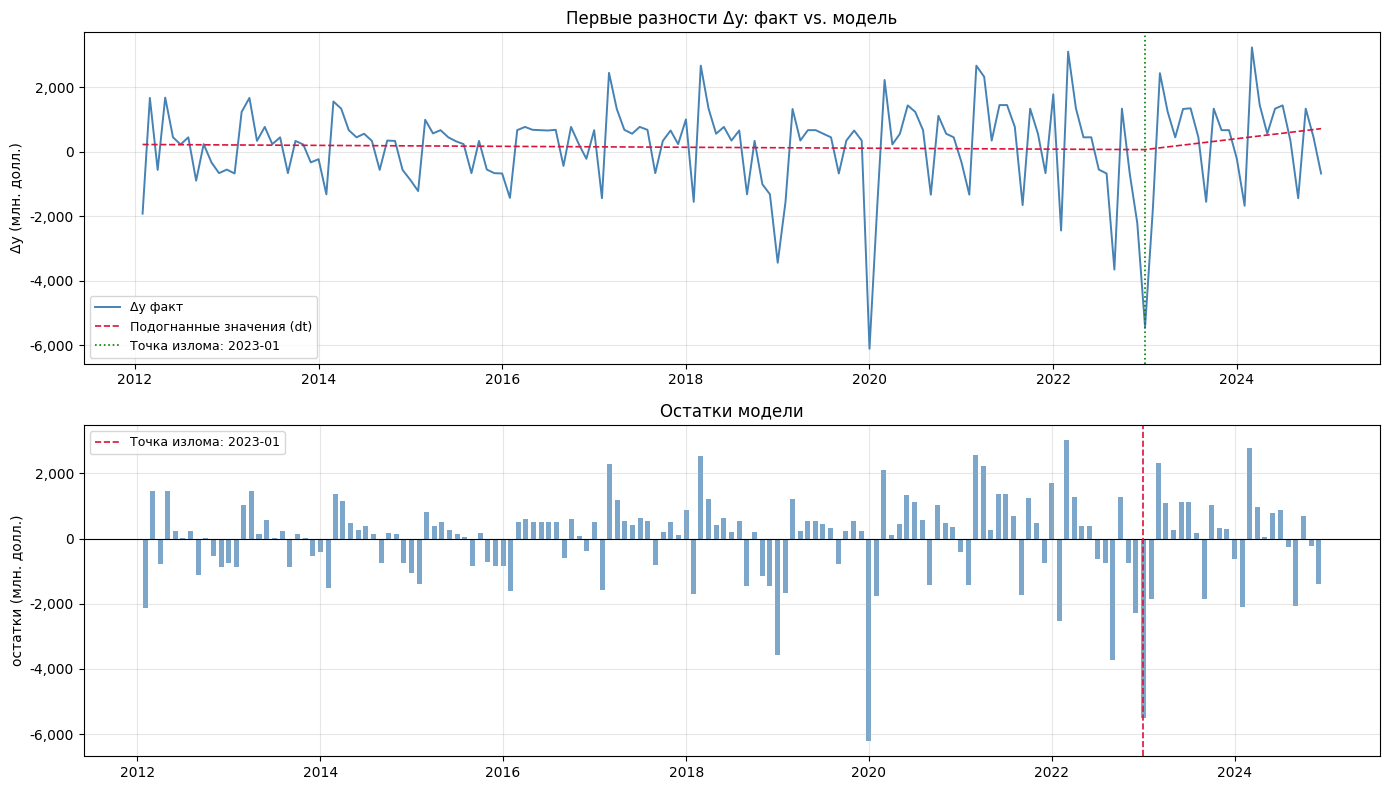

In [37]:
models_list = [('ds', res_ds), ('dt', res_dt), ('ds+dt', res_both)]
best_name, best_res = min(models_list, key=lambda x: x[1].aic)

print(f"\nЛучшая модель по AIC: {best_name}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

# Факт vs. подогнанные значения (первые разности)
axes[0].plot(model_df.index, model_df['dy'], label='Δy факт',
             color='steelblue', linewidth=1.4)
axes[0].plot(model_df.index, best_res.fittedvalues,
             label=f'Подогнанные значения ({best_name})',
             color='crimson', linewidth=1.2, linestyle='--')
axes[0].axvline(break_date, color='green', linestyle=':', linewidth=1.2,
                label=f'Точка излома: {break_date.strftime("%Y-%m")}')
axes[0].set_title(f'Первые разности Δy: факт vs. модель', fontsize=12)
axes[0].set_ylabel('Δy (млн. долл.)')
axes[0].yaxis.set_major_formatter(fmt)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Остатки
axes[1].bar(model_df.index, best_res.resid, color='steelblue', alpha=0.7, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(break_date, color='crimson', linestyle='--', linewidth=1.2,
                label=f'Точка излома: {break_date.strftime("%Y-%m")}')
axes[1].set_title('Остатки модели', fontsize=12)
axes[1].set_ylabel('остатки (млн. долл.)')
axes[1].yaxis.set_major_formatter(fmt)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Судя по тому, что фиктивные переменные незначимы - излом 2022 года является стохастическим.

## 5. Итоговое заключение

### Тест Кванда-Эндрюса
Что сделали: Прогнали тест Кванда-Эндрюса, чтобы найти точку перелома в данных. Потом попробовали учесть этот перелом с помощью фиктивных переменных ds (скачок уровня) и dt (изменение наклона).

Что получили: Тест показал, что перелом действительно есть — в декабре 2022 года. Это логично: рынок полупроводников сначала вырос после ковида, а потом резко упал из-за перепроизводства.

А вот фиктивные переменные не сработали — все p-value > 0.05. Это значит, что перелом есть, но он случайный (стохастический), а не жесткий (детерминированный). Модель его не замечает.

Вывод для следующих работ: В ЛР №4 при прогнозировании нужно просто разделить данные на две части: до декабря 2022 и после. И строить отдельные прогнозы для каждого куска.

Краткая суть работы:

Цель работы — понять, как правильно прогнозировать временной ряд, если в его середине происходит "перелом" (структурное изменение).

Зачем мы это делали:

Проблема: Обычные модели (например, те, что строили в первой работе) предполагают, что закономерности в данных не меняются. Но в реальной жизни случаются кризисы, скачки спроса или падения рынка (как в нашем примере с полупроводниками в конце 2022 года).

Решение: Нужно найти точную дату перелома и "объяснить" модели, что после этой даты правила игры изменились.

Как мы это сделали:

Нашли точку перелома с помощью теста Кванда-Эндрюса (это как «рентген», который показывает точное место перелома кости). У нас это декабрь 2022.

Ввели "флажки" (фиктивные переменные):

ds (скачок уровня) — «с этого момента значения стали в среднем выше/ниже».

ds1 (изменение наклона) — «с этого момента тренд стал расти/падать быстрее».

Проверили, помогли ли эти флажки улучшить модель.

Главный вывод в двух словах:
Даже если перелом есть (тест его показал), он может быть случайным (стохастическим), а не жестким (детерминированным). В нашем случае фиктивные переменные оказались бесполезны — модель их "не заметила". Значит, мы просто констатируем факт перелома, но при прогнозе нужно учитывать его косвенно (например, строить две разные модели: "до" и "после").

